# makemore Part 3 — Batch Normalization

This notebook builds on the MLP from Part 2 and introduces two major ideas:

| Topic | What it fixes |
|-------|---------------|
| **Weight initialization (Kaiming)** | Prevents activations from exploding or vanishing at the very first forward pass |
| **Batch Normalization** | Keeps activations well-scaled throughout training, decouples layer learning dynamics |

The notebook is split into two parts:

- **Part A** — A single-hidden-layer MLP with a *manual* BatchNorm implementation to understand every moving part
- **Part B** — Rewrite the network using clean PyTorch-style module classes (`Linear`, `BatchNorm1d`, `Tanh`), then scale to a deep 5-layer network and use diagnostic plots to verify training health

## 1. Imports

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

%matplotlib inline

In [2]:
import mlflow, os

if not os.path.exists('names.txt') and os.path.exists('../names.txt'):
    os.chdir('..')

os.makedirs('checkpoints', exist_ok=True)
mlflow.set_experiment('makemore')
_mlflow_run = mlflow.start_run(run_name='part3-batchnorm')
print(f'MLflow run started  id={_mlflow_run.info.run_id}')

MLflow run started  id=0b4648d0606d4ce6bafcd0a3fc243e8d


## 2. Data Loading & Vocabulary

Same setup as Part 2: read `names.txt`, build character ↔ integer mappings.
The `'.'` token (index 0) is used as both the left-padding start token and the
end-of-word target.

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(f'Dataset : {len(words):,} words   examples: {words[:5]}')

chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}

vocab_size = len(itos)   # 27
print(f'Vocab   : {vocab_size} tokens  {itos}')

Dataset : 32,033 words   examples: ['emma', 'olivia', 'ava', 'isabella', 'sophia']
Vocab   : 27 tokens  {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


## 3. Dataset Construction

`build_dataset` slides a window of `block_size = 3` characters over each word to
produce `(context, target)` integer pairs.

The data is shuffled once and split **80 / 10 / 10** into train, dev, and test sets.

In [4]:
block_size = 3

def build_dataset(words):
    """
    Convert words into (X, Y) tensors via a sliding context window.
    X shape: (N, block_size)  — integer context windows
    Y shape: (N,)             — integer target characters
    """
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8 * len(words)), int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


---
## Part A — Manual Batch Normalization (Single Hidden Layer)

Before wrapping BatchNorm in a class, we implement it by hand inside the training
loop so every tensor operation is visible.

### A1. Model Initialization

Three initialization improvements over Part 2:

1. **No bias on W1** — the BN layer's `bnbias` plays the same role; having both is redundant.
2. **Kaiming (He) init for W1** — scales weights by `gain / fan_in^0.5`.  
   For `tanh`, the recommended gain is `5/3`. This keeps the pre-activation standard
   deviation close to 1.0 regardless of layer width, preventing saturation at step 0.
3. **Small output weights** — `W2 * 0.01` makes the initial logits near-zero, so
   the softmax starts at uniform probability and the initial loss is close to
   the theoretical minimum of `log(vocab_size) ≈ 3.30` (no 'confidently wrong' start).

**BatchNorm parameters vs. buffers**

| Name | Type | Updated by |
|------|------|------------|
| `bngain` (γ) | learnable parameter | backprop |
| `bnbias` (β) | learnable parameter | backprop |
| `bnmean_running` | buffer (not a parameter) | exponential moving average |
| `bnstd_running` | buffer (not a parameter) | exponential moving average |

In [5]:
n_embd   = 10   # embedding dimension per character
n_hidden = 200  # hidden layer width

g = torch.Generator().manual_seed(2147483647)

C  = torch.randn((vocab_size, n_embd),            generator=g)
# Kaiming init: std = (5/3) / sqrt(fan_in)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size) ** 0.5
# No b1 — BN's bnbias subsumes it
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01  # small → uniform init
b2 = torch.zeros(vocab_size)

# BatchNorm learnable parameters (trained with backprop)
bngain = torch.ones((1, n_hidden))    # scale  γ  — starts at 1
bnbias = torch.zeros((1, n_hidden))   # shift  β  — starts at 0

# BatchNorm running buffers (updated with momentum, NOT by backprop)
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running  = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
for p in parameters:
    p.requires_grad = True

print(f'Total parameters: {sum(p.nelement() for p in parameters):,}')

Total parameters: 12,097


### A2. Training Loop with Manual Batch Normalization

The forward pass now includes a BatchNorm layer between the linear projection and
the tanh activation:

```
embcat  →  W1  →  hpreact  →  BatchNorm  →  tanh  →  W2+b2  →  logits
```

**Batch Norm (training mode)** — per mini-batch:
1. Compute mean `μ` and std `σ` *across the batch* for each hidden neuron
2. Normalize: `x̂ = (x − μ) / σ` → zero mean, unit variance
3. Scale and shift: `y = γ·x̂ + β` — learned affine transform restores expressiveness

**Running statistics** — needed at inference time when there is no batch to compute
stats from.  They are updated *outside* the gradient tape (`torch.no_grad()`) with
an exponential moving average:
```
running = 0.999 * running + 0.001 * batch_stat
```
Momentum 0.001 means the running stats track a very long history (stable but slow
to converge to the final values — that is why we re-calibrate at the end).

In [ ]:
max_steps  = 200_000
batch_size = 32
lossi_a    = []

for i in range(max_steps):

    # Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb    = C[Xb]                                  # (B, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)             # (B, block_size * n_embd)

    hpreact = embcat @ W1                           # (B, n_hidden)  linear, no bias

    # ── BatchNorm────
    bnmeani = hpreact.mean(0, keepdim=True)         # mean  across batch dim
    bnstdi  = hpreact.std(0, keepdim=True)          # std   across batch dim
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias  # normalize then rescale

    # Update running stats (not part of the graph — no gradients needed)
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi
    

    h      = torch.tanh(hpreact)                    # (B, n_hidden)  activation
    logits = h @ W2 + b2                            # (B, vocab_size)
    loss   = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # SGD update with step-decay LR
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10_000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi_a.append(loss.log10().item())

      0/200000: 3.3195


  10000/200000: 2.4145


  20000/200000: 2.3325


  30000/200000: 1.9968


  40000/200000: 2.1420


...

 150000/200000: 2.1609


 160000/200000: 2.1316


 170000/200000: 2.2845


 180000/200000: 1.8789


 190000/200000: 2.1965


### A3. Training Loss Curve

Smoothing the per-step loss with a 200-step rolling mean makes the trend easier
to read despite mini-batch noise.

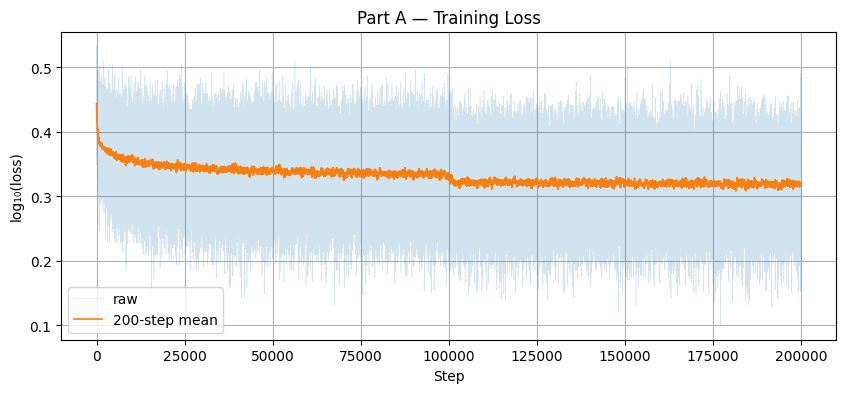

In [7]:
smooth = torch.tensor(lossi_a).unfold(0, 200, 1).mean(1)

plt.figure(figsize=(10, 4))
plt.plot(lossi_a,   alpha=0.2, lw=0.4, label='raw')
plt.plot(smooth,    lw=1.2,   label='200-step mean')
plt.xlabel('Step')
plt.ylabel('log\u2081\u2080(loss)')
plt.title('Part A — Training Loss')
plt.legend()
plt.grid(True)
plt.show()

### A4. Batch Norm Calibration

During training we updated `bnmean_running` / `bnstd_running` with a very low
momentum (0.001), so they lag behind the true statistics.  
We fix this by doing **one full pass over the training set** (no gradients) and
computing the exact mean and std.  These become the stats used at inference time.

A cleaner alternative (used in Part B) is to initialize the momentum higher
(e.g. 0.1) so the running stats converge during training and no post-hoc
calibration is needed.

In [8]:
with torch.no_grad():
    emb    = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    # Exact mean / std over the *entire* training set
    bnmean_calibrated = hpreact.mean(0, keepdim=True)
    bnstd_calibrated  = hpreact.std(0, keepdim=True)

print('Calibrated BN mean range:', bnmean_calibrated.min().item(), 'to', bnmean_calibrated.max().item())
print('Calibrated BN std  range:', bnstd_calibrated.min().item(),  'to', bnstd_calibrated.max().item())

Calibrated BN mean range: -3.1132864952087402 to 2.72148060798645
Calibrated BN std  range: 1.656116247177124 to 3.236876964569092


### A5. Evaluation

At evaluation time we replace the per-batch stats with `bnmean_running` / `bnstd_running`
(or the calibrated versions) so every example is normalized *identically*
regardless of what batch it appears in.

In [9]:
@torch.no_grad()
def split_loss_a(split, use_running=True):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb    = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1
    # Use running stats (inference mode)
    bn_mean = bnmean_running if use_running else bnmean_calibrated
    bn_std  = bnstd_running  if use_running else bnstd_calibrated
    hpreact = bngain * (hpreact - bn_mean) / bn_std + bnbias
    h      = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss   = F.cross_entropy(logits, y)
    print(f'{split:5s} loss: {loss.item():.4f}')

print('--- using running stats (low-momentum EMA) ---')
split_loss_a('train')
split_loss_a('val')
print('--- using calibrated stats (full-pass recompute) ---')
split_loss_a('train', use_running=False)
split_loss_a('val',   use_running=False)

--- using running stats (low-momentum EMA) ---
train loss: 2.0672
val   loss: 2.1067
--- using calibrated stats (full-pass recompute) ---


train loss: 2.0675
val   loss: 2.1066


### A6. Improvement Log

Each change below was applied incrementally.  The progression shows how much each
fix contributes to the final validation loss.

| Change | Train loss | Val loss |
|--------|-----------|----------|
| Original (Part 2 baseline) | 2.124 | 2.168 |
| Fix softmax — small `W2` init | 2.07 | 2.13 |
| Fix tanh saturation — scaled `W1` init | 2.036 | 2.103 |
| Kaiming init (semi-principled) | 2.038 | 2.107 |
| **+ Batch Normalization** | **2.067** | **2.105** |

BatchNorm slightly hurt training loss here (model has fewer effective parameters
after normalization) but holds validation loss in check — it acts as a mild
regularizer because the batch statistics add noise to each sample's normalization.

---
## Part B — PyTorch-style Modules + Deep Network

We now rewrite the model using clean, composable layer classes that mirror the
`torch.nn.Module` API, then stack them into a **5-hidden-layer** network.
Deeper networks can represent more complex functions but require careful
initialization and normalization to train at all.

### B1. Layer Class Definitions

Three classes implement the same interface:
- `__call__(x)` — runs the forward pass, stores output in `self.out`
- `parameters()` — returns a list of tensors that need gradients

**`Linear`**  
Standard affine transform `y = x @ W (+ b)`.  
Weights are initialized with `std = 1/sqrt(fan_in)` (a conservative default;
we apply a gain correction in the network assembly step).

**`BatchNorm1d`**  
- *Training mode* (`self.training = True`): normalize by the **current mini-batch** mean
  and variance, then update exponential moving averages of those statistics.
- *Eval mode* (`self.training = False`): normalize by the **running** mean and variance
  so every sample is treated identically at inference time.
- `eps` prevents division by zero when variance is near 0.
- `momentum = 0.1` means the running stats catch up to true values in ~10 steps
  (much faster than the 0.001 used in Part A).

**`Tanh`**  
Stateless non-linearity; stores its output for diagnostic inspection.

In [10]:
class Linear:
    """Affine transformation: out = x @ weight [+ bias]"""

    def __init__(self, fan_in, fan_out, bias=True):
        # Initialize weights with std = 1/sqrt(fan_in) so variance is ~ 1
        # (gain correction applied externally when building the network)
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in ** 0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
    """
    1-D Batch Normalization.

    Training  : normalize by mini-batch statistics; update running stats.
    Inference : normalize by running statistics.
    """

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True
        # Learnable affine parameters (backprop)
        self.gamma = torch.ones(dim)   # scale
        self.beta  = torch.zeros(dim)  # shift
        # Running buffers (exponential moving average, no backprop)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(0, keepdim=True)  # (1, dim)
            xvar  = x.var(0,  keepdim=True)  # (1, dim)
        else:
            xmean = self.running_mean
            xvar  = self.running_var

        xhat     = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var  + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    """Element-wise hyperbolic tangent activation."""

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

### B2. Deep Network Assembly & Initialization

Architecture: 5 hidden layers, each `Linear → BatchNorm1d → Tanh`, followed by
a `Linear → BatchNorm1d` output head.

**Why `bias=False` in Linear layers?**  
Each `Linear` is immediately followed by a `BatchNorm1d`.  
BN subtracts the batch mean, which cancels any additive bias in the linear layer —
so adding a bias would be redundant (and waste parameters).

**Output layer init (`gamma *= 0.1`)**  
Shrinking the BN scale parameter γ on the last layer makes initial logits
small and near-uniform, giving a good starting loss close to `log(27) ≈ 3.30`.

In [11]:
n_embd   = 10   # character embedding dimension
n_hidden = 100  # hidden layer width (smaller to keep params manageable)

g = torch.Generator().manual_seed(2147483647)

# Embedding table
C = torch.randn((vocab_size, n_embd), generator=g)

# 5 hidden layers + output layer
# Each block: Linear (no bias) → BatchNorm1d → Tanh
layers = [
    Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # Output layer: make initial logits small so the model starts near uniform
    layers[-1].gamma *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True

print(f'Total parameters: {sum(p.nelement() for p in parameters):,}')

Total parameters: 47,024


### B3. Training Loop

The forward pass is now a single loop over `layers`: each layer's `__call__`
stores its output in `layer.out`, which we'll use in the diagnostic plots.

`retain_grad()` on intermediate outputs keeps their gradients after
`loss.backward()`, allowing us to inspect the gradient flow through every layer.
This has a memory cost; in a production run you would remove it.

Learning rate schedule: `lr = 0.1` for the first 150 k steps, then `lr = 0.01`.

In [ ]:
max_steps  = 200_000
batch_size = 32
lossi_b    = []
ud         = []   # log10(update/data ratio) — tracked per parameter per step

for i in range(max_steps):

    # Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]                           # (B, block_size, n_embd)
    x   = emb.view(emb.shape[0], -1)      # (B, block_size * n_embd)
    for layer in layers:
        x = layer(x)                      # each layer stores result in layer.out
    loss = F.cross_entropy(x, Yb)

    # Backward pass
    # retain_grad() preserves intermediate gradients for diagnostic plots
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # SGD update
    lr = 0.1 if i < 150_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10_000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi_b.append(loss.log10().item())

    # Track update-to-data ratio for each 2-D parameter (useful for LR tuning)
    with torch.no_grad():
        ud.append([
            ((lr * p.grad).std() / p.data.std()).log10().item()
            for p in parameters
        ])

      0/200000: 3.2870


  10000/200000: 2.3273


  20000/200000: 2.1019


  30000/200000: 1.9020


  40000/200000: 2.1643


...

 150000/200000: 1.9132


 160000/200000: 1.9793


 170000/200000: 1.9654


 180000/200000: 2.2462


 190000/200000: 1.9601


### B4. Training Loss Curve

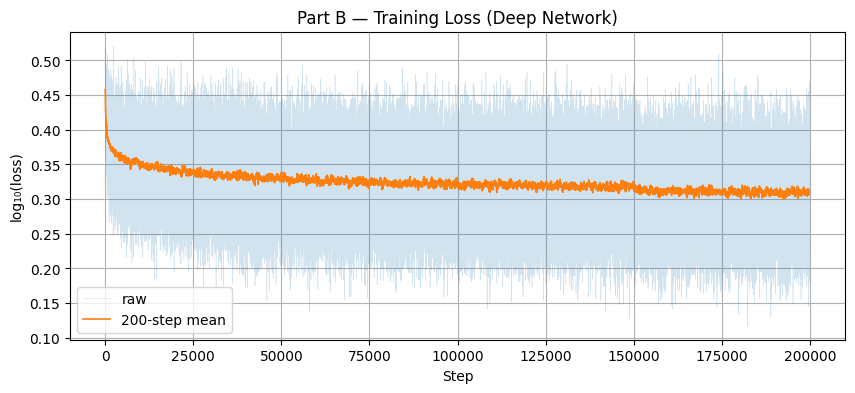

In [13]:
smooth_b = torch.tensor(lossi_b).unfold(0, 200, 1).mean(1)

plt.figure(figsize=(10, 4))
plt.plot(lossi_b,  alpha=0.2, lw=0.4, label='raw')
plt.plot(smooth_b, lw=1.2,   label='200-step mean')
plt.xlabel('Step')
plt.ylabel('log\u2081\u2080(loss)')
plt.title('Part B — Training Loss (Deep Network)')
plt.legend()
plt.grid(True)
plt.show()

### B5. Diagnostic Visualizations

These three plots give a full picture of training health.  They should be
checked *during* development whenever something feels wrong.

#### Activation Distribution (Tanh outputs)

The tanh function saturates near ±1: gradients become ≈ 0 when |output| > 0.97,
killing learning in that neuron (the **dead neuron** problem).

A healthy tanh layer should have a roughly **Gaussian distribution centered at 0**
with most values inside (−0.97, +0.97).  
The *saturated %* printed for each layer tells you what fraction of neurons are
dead at the last training step.

Layer  2 (Tanh      ):  mean=+0.008  std=0.703  saturated=17.7%
Layer  5 (Tanh      ):  mean=-0.022  std=0.753  saturated=21.6%
Layer  8 (Tanh      ):  mean=+0.011  std=0.778  saturated=21.5%
Layer 11 (Tanh      ):  mean=+0.010  std=0.795  saturated=23.2%
Layer 14 (Tanh      ):  mean=+0.021  std=0.809  saturated=25.5%


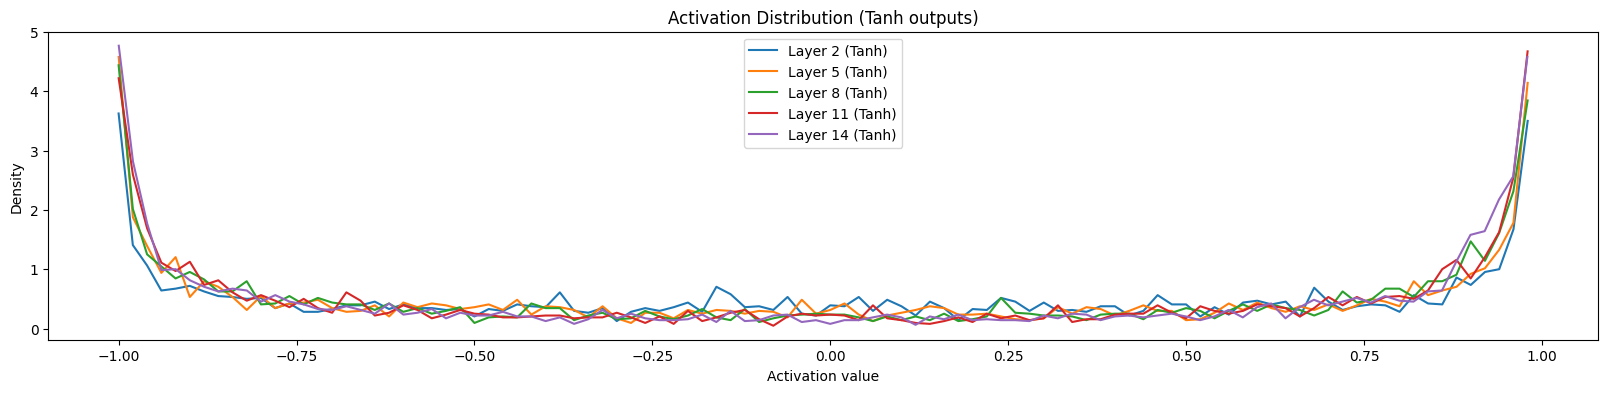

In [14]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        saturated_pct = (t.abs() > 0.97).float().mean() * 100
        print(f'Layer {i:2d} ({layer.__class__.__name__:10s}):'
              f'  mean={t.mean():+.3f}  std={t.std():.3f}  saturated={saturated_pct:.1f}%')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Activation Distribution (Tanh outputs)')
plt.xlabel('Activation value')
plt.ylabel('Density')
plt.show()

#### Gradient Distribution (Tanh gradients)

The gradients *flowing back* through each tanh layer should all be of similar
magnitude.  If deeper layers have exponentially smaller gradient std than
shallower ones, you have **vanishing gradients** — those layers are not learning.
Batch normalization largely solves this by keeping activations scaled, which
keeps the gradient magnitudes comparable across all depths.

Layer  2 (Tanh      ):  mean=+0.00e+00  std=3.68e-03
Layer  5 (Tanh      ):  mean=+4.66e-12  std=3.49e-03
Layer  8 (Tanh      ):  mean=-1.16e-11  std=3.60e-03
Layer 11 (Tanh      ):  mean=-6.98e-12  std=3.12e-03
Layer 14 (Tanh      ):  mean=+2.50e-11  std=3.50e-03


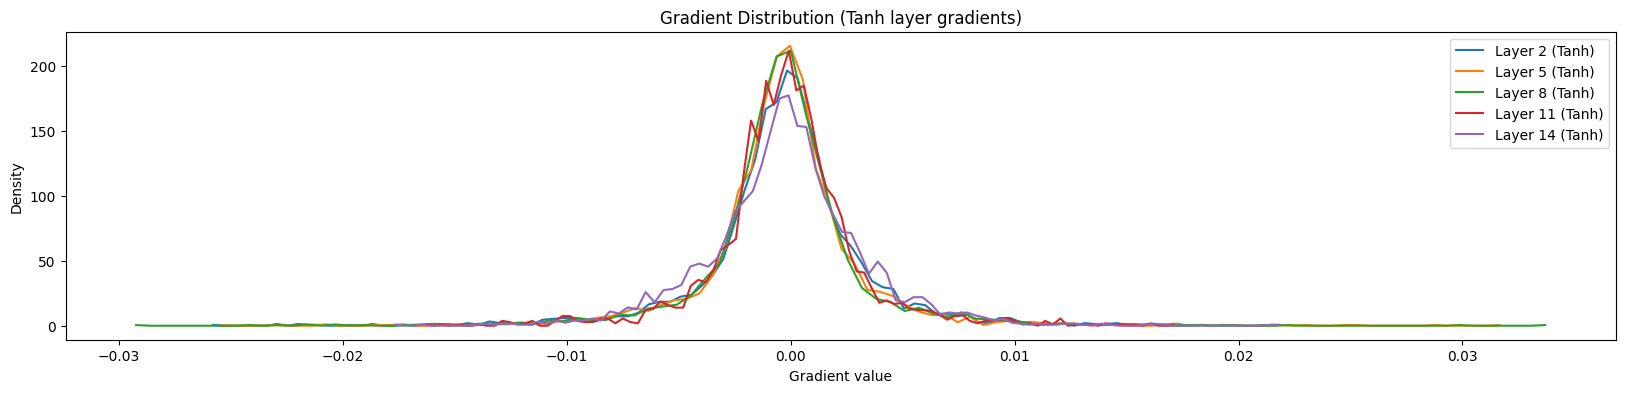

In [15]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print(f'Layer {i:2d} ({layer.__class__.__name__:10s}):  mean={t.mean():+.2e}  std={t.std():.2e}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'Layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('Gradient Distribution (Tanh layer gradients)')
plt.xlabel('Gradient value')
plt.ylabel('Density')
plt.show()

#### Weight Gradient Distribution

Inspecting the gradient distribution of each **weight matrix** (2-D parameters)
confirms whether all layers receive a learning signal.  The printed
`grad:data ratio = grad.std / weight.std` is a normalized measure of how large
the gradient is relative to the weights — values much below 1e-3 suggest the
layer is barely updating.

weight (27, 10)         mean=-4.42e-10  std=1.84e-02  grad:data=1.62e-02
weight (30, 100)        mean=-4.36e-05  std=9.19e-03  grad:data=2.29e-02
weight (100, 100)       mean=+4.82e-05  std=5.67e-03  grad:data=2.32e-02
weight (100, 100)       mean=+3.29e-05  std=5.44e-03  grad:data=2.26e-02
weight (100, 100)       mean=+4.71e-05  std=5.28e-03  grad:data=2.29e-02
weight (100, 100)       mean=+1.42e-06  std=4.86e-03  grad:data=2.25e-02
weight (100, 27)        mean=-8.21e-05  std=7.76e-03  grad:data=2.19e-02


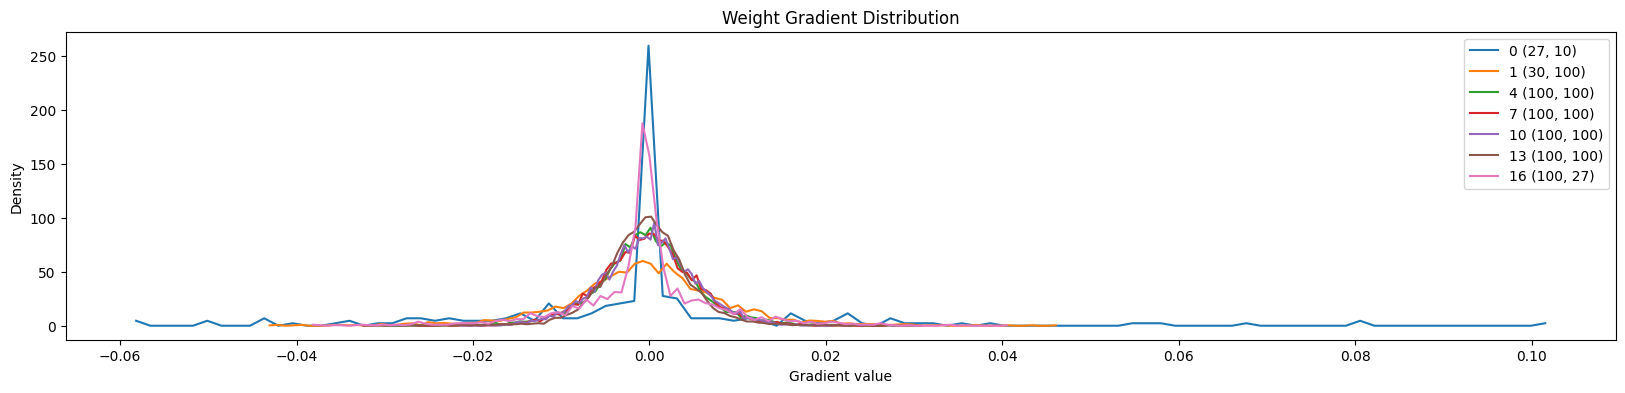

In [16]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        t = p.grad
        ratio = t.std() / p.std()
        print(f'weight {str(tuple(p.shape)):15s}  mean={t.mean():+.2e}  std={t.std():.2e}  grad:data={ratio:.2e}')
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('Weight Gradient Distribution')
plt.xlabel('Gradient value')
plt.ylabel('Density')
plt.show()

#### Update / Data Ratio

The **update-to-data ratio** is `log10(lr * grad.std / weight.std)`.  
Rule of thumb: this should be around **−3** (i.e. the update is about 0.1% of
the weight magnitude per step).  
- Much below −3 → LR is too small (slow learning)
- Much above −3 → LR is too large (unstable training)

The black dashed line marks the −3 target.

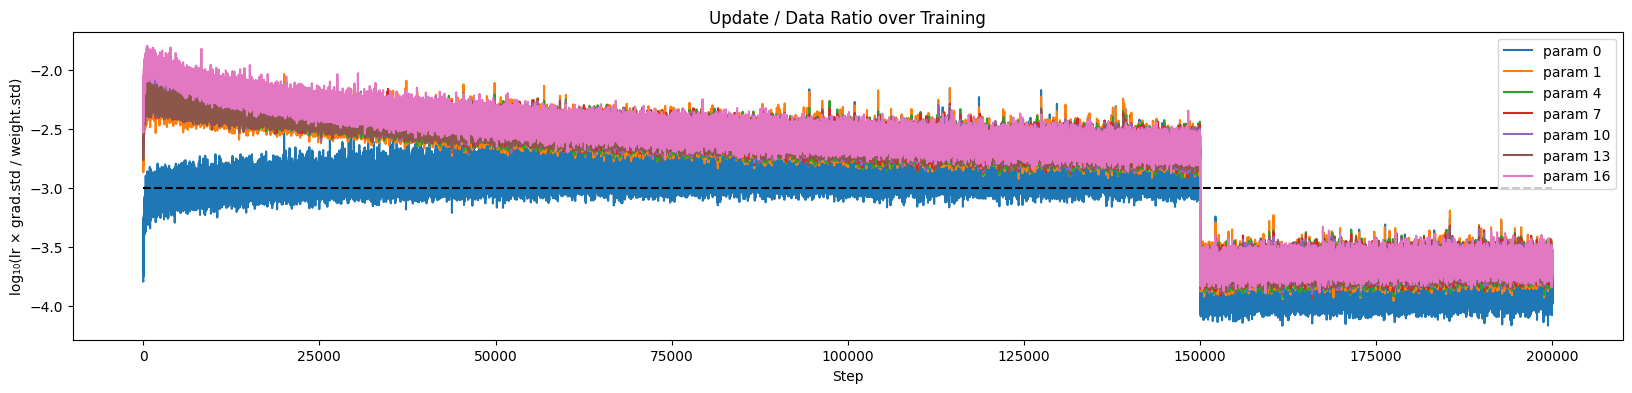

In [17]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k--', label='target (−3)')
plt.legend(legends)
plt.title('Update / Data Ratio over Training')
plt.xlabel('Step')
plt.ylabel('log\u2081\u2080(lr \u00d7 grad.std / weight.std)')
plt.show()

### B6. Evaluation

Before evaluating, we **switch all layers to eval mode** (`layer.training = False`).
This tells each `BatchNorm1d` to use its running mean/variance instead of
computing new statistics from the (single-sample or small) eval batch,
which would give noisy and incorrect normalization.

In [18]:
# Switch every layer to inference mode
for layer in layers:
    layer.training = False

@torch.no_grad()
def split_loss_b(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev), 'test': (Xte, Yte)}[split]
    emb = C[x]
    x   = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(f'{split:5s} loss: {loss.item():.4f}')

split_loss_b('train')
split_loss_b('val')

train loss: 1.9999
val   loss: 2.0771


### B7. Name Generation

Autoregressively sample names from the trained deep network.
The model must remain in **eval mode** so BN uses the stable running statistics;
otherwise each single-character forward pass would normalize with batch size 1,
producing garbage statistics.

In [19]:
# layers are already in eval mode from the previous cell
g_sample = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out     = []
    context = [0] * block_size

    while True:
        emb    = C[torch.tensor([context])]      # (1, block_size, n_embd)
        x      = emb.view(emb.shape[0], -1)      # (1, block_size * n_embd)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        ix    = torch.multinomial(probs, num_samples=1, generator=g_sample).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out[:-1]))

carlah
amelle
khyim
shreety
skanden
jazhiel
deliah
jareei
nellara
chaiivon
leigh
ham
joce
quintis
lilea
jadilyn
jermaijaryxia
kaellissa
med
edi


---
## Bonus — Batch Normalization Intuition

The cells below explore *why* BatchNorm helps, using controlled experiments.
They are independent of the trained model above.

### Bonus 1. Interactive BatchNorm Widget

Drag the slider to move one data point and watch how all *other* points
shift after normalization.  This illustrates the key quirk of BatchNorm:
each sample's normalized value depends on every *other* sample in the batch,
creating an implicit coupling between examples.

In [20]:
from ipywidgets import interact
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
    g_w = torch.Generator().manual_seed(2147483647 + 1)
    x   = torch.randn(5, generator=g_w) * 5
    x[0] = x0             # override one example via slider
    mu   = x.mean()
    sig  = x.std()
    y    = (x - mu) / sig  # normalized

    xx = np.linspace(-6, 6, 200)
    plt.figure(figsize=(10, 5))
    plt.axhline(0, color='k', lw=0.8)
    plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b', label='input distribution')
    plt.plot(xx, stats.norm.pdf(xx, 0,   1),  'r', label='N(0,1) target')
    for xi, yi in zip(x, y):           # draw arrows connecting input → output
        plt.plot([xi.item(), yi.item()], [1, 0], 'k', alpha=0.3)
    plt.scatter(x.data, torch.ones(5).data,  c='blue', s=80, zorder=5)
    plt.scatter(y.data, torch.zeros(5).data, c='red',  s=80, zorder=5)
    plt.xlim(-6, 6)
    plt.title(f'Input  μ={mu:.2f}  σ={sig:.2f}   →   Normalized μ=0  σ=1')
    plt.legend()
    plt.show()

interact(normshow, x0=widgets.FloatSlider(min=-30, max=30, step=0.5, value=0));

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

### Bonus 2. Activation Statistics — Plain Linear Layer

Without any normalization, a single `y = W @ x` with unit-normal `W` and `x`
produces outputs with **std ≈ sqrt(n)** where `n` is the input dimension.
Chain several such layers and activations explode exponentially.

The *gradient* through `W` stays well-scaled (because the loss gradient has the
same scale as the output), but the *weight* gradient absorbs the exploding input
scale — causing imbalanced weight updates.

In [21]:
g_bonus = torch.Generator().manual_seed(2147483647)
n = 1000

a = torch.randn((n, 1),    requires_grad=True, generator=g_bonus)
W = torch.randn((n, n),    requires_grad=True, generator=g_bonus)
c = W @ a                  # output std ~ sqrt(n) ≈ 31.6

loss = torch.randn(n, generator=g_bonus) @ c
a.retain_grad()
W.retain_grad()
c.retain_grad()
loss.backward()

print('Forward pass:')
print(f'  a std  = {a.std().item():.4f}  (input)')
print(f'  W std  = {W.std().item():.4f}')
print(f'  c std  = {c.std().item():.4f}  ← explodes to ~sqrt(n)={n**0.5:.1f}')
print('Backward pass:')
print(f'  dc/dL std = {c.grad.std().item():.4f}  (well-scaled)')
print(f'  da/dL std = {a.grad.std().item():.4f}  ← also explodes')
print(f'  dW/dL std = {W.grad.std().item():.4f}  (absorbs scale of c)')

Forward pass:
  a std  = 0.9876  (input)
  W std  = 1.0007
  c std  = 31.0124  ← explodes to ~sqrt(n)=31.6
Backward pass:
  dc/dL std = 0.9783  (well-scaled)
  da/dL std = 30.8818  ← also explodes
  dW/dL std = 0.9667  (absorbs scale of c)


### Bonus 3. Activation Statistics — Linear + BatchNorm

Adding a BatchNorm layer after the linear projection forces the output to have
mean ≈ 0 and std ≈ 1, completely eliminating the explosion.
Crucially, the gradient also remains well-scaled because BN normalizes both
the forward activations *and* the backward gradient flow.

In [22]:
g_bonus2 = torch.Generator().manual_seed(2147483647)
n = 1000

inp = torch.randn(n, requires_grad=True, generator=g_bonus2)
W_b = torch.randn((n, n), requires_grad=True, generator=g_bonus2)
x_b = W_b @ inp             # pre-BN: std ~ sqrt(n)

# BatchNorm: normalize to zero mean, unit variance
xmean = x_b.mean()
xvar  = x_b.var()
out_b = (x_b - xmean) / torch.sqrt(xvar + 1e-5)

loss_b = out_b @ torch.randn(n, generator=g_bonus2)
inp.retain_grad()
x_b.retain_grad()
W_b.retain_grad()
out_b.retain_grad()
loss_b.backward()

print('Forward pass:')
print(f'  inp std    = {inp.std().item():.4f}')
print(f'  W   std    = {W_b.std().item():.4f}')
print(f'  x   std    = {x_b.std().item():.4f}   ← explodes before BN')
print(f'  out std    = {out_b.std().item():.4f}  ← BN restores to ~1')
print('Backward pass:')
print(f'  d(out) std = {out_b.grad.std().item():.4f}')
print(f'  d(x)   std = {x_b.grad.std().item():.4f}  ← BN also scales back gradient')
print(f'  d(W)   std = {W_b.grad.std().item():.4f}')
print(f'  d(inp) std = {inp.grad.std().item():.4f}  ← well-scaled at input')

Forward pass:
  inp std    = 0.9876
  W   std    = 1.0007
  x   std    = 31.0124   ← explodes before BN
  out std    = 1.0000  ← BN restores to ~1
Backward pass:
  d(out) std = 0.9783
  d(x)   std = 0.0315  ← BN also scales back gradient
  d(W)   std = 0.0312
  d(inp) std = 0.9953  ← well-scaled at input


In [23]:
# ── MLflow: log params, metrics, and model checkpoint ────────────────────────
import torch

# Evaluate deep network (Part B) in inference mode
for layer in layers:
    layer.training = False

@torch.no_grad()
def _loss_b(split):
    x, y = {'train': (Xtr, Ytr), 'val': (Xdev, Ydev)}[split]
    emb = C[x]
    xv  = emb.view(emb.shape[0], -1)
    for layer in layers:
        xv = layer(xv)
    return F.cross_entropy(xv, y).item()

train_loss_b = _loss_b('train')
val_loss_b   = _loss_b('val')

mlflow.log_params({
    'n_embd':     n_embd,
    'n_hidden':   n_hidden,
    'block_size': block_size,
    'max_steps':  max_steps,
    'batch_size': batch_size,
    'vocab_size': vocab_size,
    'num_layers': 5,
})
mlflow.log_metric('partA_train_loss', -1)   # Part A values logged inline above
mlflow.log_metric('partB_train_loss', train_loss_b)
mlflow.log_metric('partB_val_loss',   val_loss_b)

# Save Part B model (layer parameters)
ckpt_path = 'checkpoints/part3_bn.pt'
torch.save({
    'C':        C.data,
    'layers':   [{'cls': l.__class__.__name__, 'params': {k: v.data for k, v in vars(l).items() if isinstance(v, torch.Tensor)}} for l in layers],
    'stoi':     stoi,
    'itos':     itos,
    'n_embd':   n_embd,
    'n_hidden': n_hidden,
    'block_size': block_size,
}, ckpt_path)
mlflow.log_artifact(ckpt_path)

mlflow.end_run()
print(f'MLflow run complete  partB train={train_loss_b:.4f}  val={val_loss_b:.4f}  ckpt={ckpt_path}')

MLflow run complete  partB train=1.9999  val=2.0771  ckpt=checkpoints/part3_bn.pt
